In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qick_workspace.tools import system_cfg

from qick import *
from qick.pyro import make_proxy
from qick import QickConfig
from qick.asm_v2 import QickSpan, QickSweep1D
import Pyro4
from qick_workspace.scrip.base_experiment import BaseExperiment
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
print(soccfg)

file_path = r'D:\Labber_Data\Jay\twpa'
BaseExperiment.setup(soc, soccfg, file_path)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_a26a06964c834b27b9923f561f181a5d@192.168.10.82:41297
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230 on JHC3, or QICK box DAC port 8
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 4096 complex samples (0.427 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230 on JHC4, or QICK box DAC port 9
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 8192 complex samples (0.855 us)
		32-bit DDS, range=9584.

In [3]:
from qick_workspace.tools.system_tool import ExperimentConfig
from qick_workspace.tools.system_cfg import config_list

qubit = "Q1"
config_all = ExperimentConfig(config_list)
run_cfg = config_all.get_qubit(qubit)

c:\Users\cluster\Desktop\SQC_soc-main\qick_workspace\tools\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


abcd_rf_fit result:
 {'Fres(GHz)': np.float64(6.5321), 'Qi': -20901, 'absQc': 377, 'Ql': 384, 'κ(MHz)': np.float64(17.03)}
Data saved to D:\Labber_Data\Jay\twpa\2026\04\Data_0420\s002_onetone_ge_Q1_003


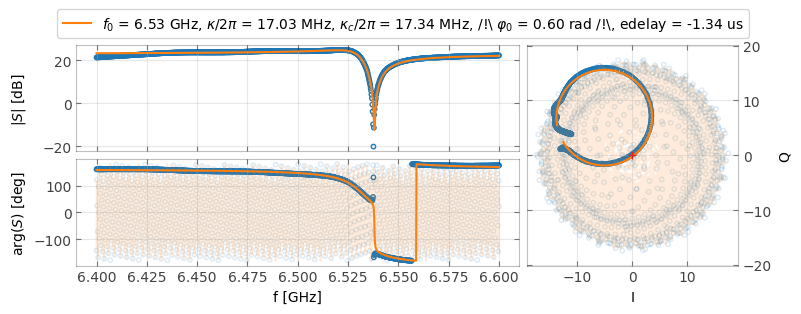

In [16]:
from qick_workspace.scrip.s002_res_spec_ge import ResonatorSpec

START_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] - 10  # [MHz]
STOP_FREQ = config_all.get_qubit(qubit)["res_freq_ge"] + 10  # [MHz]
START_FREQ = 6500-100  # [MHz]
STOP_FREQ = 6500+100  # [MHz]


STEPS = 1001

config_all.update("res.res_gain_ge", 0.05, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
    ]
)

onetone = ResonatorSpec(run_cfg)
result = onetone.run(py_avg=5, solve_type="hm")
## update value ##
config_all.update("res_freq_ge", round(result['Fres(GHz)']*1e3, 4), q_index=qubit)
onetone.saveLabber(qubit, yoko_value=None, config_all=config_all)

In [17]:
from qick_workspace.tools.YOKOGS200 import YOKOGS200
import pyvisa

rm = pyvisa.ResourceManager()
yoko_connect = "USB0::0x0B21::0x0039::91S522309::INSTR"
yoko = YOKOGS200(yoko_connect, rm)

# yoko.OutputOn()
yoko.OutputOff()

In [15]:
yoko.SetMode("current")
yoko.current_ramp_step = 1e-8
yoko.ramp_interval = 0.01
yokocurrent = 0* 1e-6
yoko.SetCurrent(yokocurrent)
yoko_value = yoko.GetValue()

Setting Current:   0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: Interrupted at Yoko step: 2


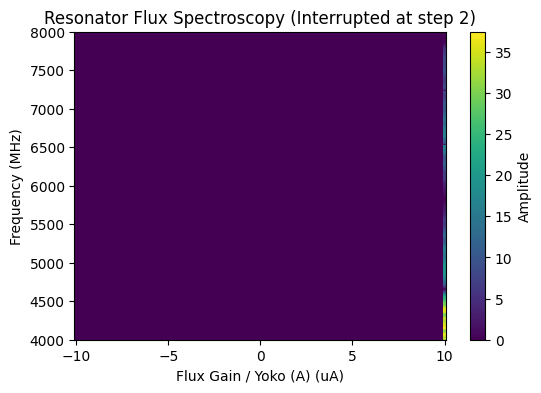

Experiment interrupted at 2 averages. Fit is based on partial data.


In [ ]:
from qick_workspace.scrip.s002c_res_spec_ge_flux import ResonatorSpecFlux
import numpy as np

START_FREQ = 4000  # [MHz]
STOP_FREQ = 8000  # [MHz]
STEPS = 1001

Start_flux = 0.01
Stop_flux = -0.01
Steps_flux = 101
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux) * 1e-6


config_all.update("res.res_gain_ge", 0.05, q_index=qubit)
run_cfg = config_all.get_qubit(qubit)

run_cfg.update(
    [
        ("steps", STEPS),
        ("res_freq_ge", QickSweep1D("freqloop", START_FREQ, STOP_FREQ)),
        ("relax_delay", 0),
        ("yoko_value", yoko_range), 
    ]
)

onetone_flux = ResonatorSpecFlux(run_cfg)
onetone_flux.run(
    10,  yoko_inst_addr=yoko_connect, yoko_mode="current"
)